## Import Libraries and Functions

In [17]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import display

import hierarchical_position_classifier as hpc_module

importlib.reload(hpc_module)

from hierarchical_position_classifier import (
    combine_position_experiment_summaries,
    per_room_hierarchical_summary,
    run_global_position_experiments_by_split,
    run_hierarchical_position_experiments_by_split,
    summarize_distance_errors,
)
from utils.csi_preprocessing import process_magnitude_data
from utils.feature_pipeline import build_frequency_feature_dataframes
import utils.graphs as graphs

importlib.reload(graphs)

from utils.graphs import (
    plot_band_error_boxplot,
    plot_band_error_cdf,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_position_confusion_by_true_room,
    plot_position_confusion_when_room_correct,
)
from utils.import_data import get_csv_files, sort_meta_info
from utils.thesis_csv_processing import process_csv_files

## Configuration

In [2]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "CSI DATA"
CALIBRATION_MODE = "none"

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "apply_agc_compensation": False,
    "agc_reference": "median",
    "filter_method": "none",
    "filter_window": 5,
    "normalization": "none",
    "epsilon": 1e-8,
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 60,
    "overlap_size": 30,
    "calibrate": False,
    "require_all_esps": False,
}

# ESP-to-room assignment for the local-ESP hierarchical classifier.
ROOM_LOCAL_ESPS = {
    1: (
        "esp_06", "esp_07", "esp_08", "esp_09", "esp_10",
        "esp_16", "esp_17", "esp_18", "esp_19", "esp_20",
    ),
    2: ("esp_01", "esp_02", "esp_03", "esp_11", "esp_12", "esp_13"),
    3: ("esp_04", "esp_05", "esp_14", "esp_15"),
}

# Experiment parameters.
SPLIT_MODES = ("group", "random")
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0

# Dataset shown in confusion matrix and floor plan cells.
CONFUSION_DATASET = "Fusion"   # "2.4 GHz", "5 GHz", or "Fusion"

# Toggle plot sections.
SHOW_CDF_PLOTS = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = False
SHOW_PER_ROOM_PLOTS = False

## Data Loading and Preprocessing

In [3]:
all_data_files = get_csv_files(str(DATA_DIR))
scenarios_id, locations_id, users_id, esps_id, trials_id = sort_meta_info(str(DATA_DIR))
print(f"Scenarios present: {', '.join(scenarios_id) or 'none'}")
print(f"Locations: {len(locations_id)}  |  Users: {len(users_id)}  |  ESPs: {len(esps_id)}")

Scenarios present: 1
Locations: 53  |  Users: 5  |  ESPs: 19


In [4]:
magnitude_data, agc_gain_data, csv_diagnostics = process_csv_files(
    all_data_files,
    return_diagnostics=True,
    calibration_mode=CALIBRATION_MODE,
    **CSV_PROCESSING_OPTIONS,
)

In [5]:
processed_magnitude_data, _ = process_magnitude_data(
    magnitude_data,
    agc_gain_data,
    **MAGNITUDE_PROCESSING_OPTIONS,
)

In [6]:
df_24ghz, df_5ghz, df_fusion = build_frequency_feature_dataframes(
    processed_magnitude_data,
    **FEATURE_EXTRACTION_OPTIONS,
)

feature_dataframes = {
    "2.4 GHz": df_24ghz,
    "5 GHz": df_5ghz,
    "Fusion": df_fusion,
}

for name, df in feature_dataframes.items():
    print(f"{name}: {df.shape[0]} windows, {df.shape[1]} columns")

2.4 GHz: 15452 windows, 2708 columns
5 GHz: 5078 windows, 3368 columns
Fusion: 5077 windows, 6068 columns


## Experiments

### Global Position Classifier

In [7]:
global_summary, global_preds_by_split, global_models_by_split = (
    run_global_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
)
display(global_summary)

,dataset,split,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,group,0.093325,2.367622,1.414214,3.181561,4629.0
1,5 GHz,group,0.096667,1.821571,1.414214,2.330372,1500.0
2,Fusion,group,0.102667,1.858266,1.414214,2.521795,1500.0
3,2.4 GHz,random,0.975841,0.052381,0.000000,0.427128,4636.0
4,5 GHz,random,0.972441,0.055945,0.000000,0.400235,1524.0
5,Fusion,random,0.986877,0.024742,0.000000,0.235860,1524.0


### Hierarchical Position Classifier — Local ESPs

In [8]:
hier_local_summary, hier_local_preds, hier_local_models = (
    run_hierarchical_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
        esp_mode="local",
        room_local_esps=ROOM_LOCAL_ESPS,
    )
)
display(hier_local_summary)

,dataset,split,esp_mode,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,distance_error_samples,localization_samples,samples
0,2.4 GHz,group,local,0.854396,0.078419,2.924051,2.000000,3.997058,4505.0,4507.0,4629.0
1,5 GHz,group,local,0.925333,0.090000,1.995830,1.414214,2.698443,1456.0,1456.0,1500.0
2,Fusion,group,local,0.934000,0.095333,1.925792,1.414214,2.580171,1456.0,1456.0,1500.0
3,2.4 GHz,random,local,0.992666,0.927308,0.172398,0.000000,0.858914,4545.0,4545.0,4636.0
4,5 GHz,random,local,0.996063,0.940289,0.097552,0.000000,0.449903,1492.0,1492.0,1524.0
5,Fusion,random,local,0.997375,0.969160,0.063146,0.000000,0.466721,1492.0,1492.0,1524.0


## Summary Table

In [9]:
combined_summary = combine_position_experiment_summaries(
    global_summary,
    hier_local_summary,
    pd.DataFrame(),
)
display(combined_summary)

,dataset,model,split,room,esp_mode,position_accuracy,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,global_position_rf,group,all,all,0.093325,NaN,2.367622,1.414214,3.181561,4629.0
1,5 GHz,global_position_rf,group,all,all,0.096667,NaN,1.821571,1.414214,2.330372,1500.0
2,Fusion,global_position_rf,group,all,all,0.102667,NaN,1.858266,1.414214,2.521795,1500.0
3,2.4 GHz,global_position_rf,random,all,all,0.975841,NaN,0.052381,0.000000,0.427128,4636.0
4,5 GHz,global_position_rf,random,all,all,0.972441,NaN,0.055945,0.000000,0.400235,1524.0
5,Fusion,global_position_rf,random,all,all,0.986877,NaN,0.024742,0.000000,0.235860,1524.0
6,2.4 GHz,hierarchical_rf,group,all,local,0.078419,0.854396,2.924051,2.000000,3.997058,4629.0
7,5 GHz,hierarchical_rf,group,all,local,0.090000,0.925333,1.995830,1.414214,2.698443,1500.0
8,Fusion,hierarchical_rf,group,all,local,0.095333,0.934000,1.925792,1.414214,2.580171,1500.0
9,2.4 GHz,hierarchical_rf,random,all,local,0.927308,0.992666,0.172398,0.000000,0.858914,4636.0


## Localization Error Analysis

In [10]:
# Concatenate all predictions for each model, preserving the dataset and split columns.
def _concat_preds(preds_dict: dict, model_label: str) -> pd.DataFrame:
    frames = [df.assign(model=model_label) for df in preds_dict.values() if not df.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


global_all = _concat_preds(global_preds_by_split, "Global")
hier_local_all = _concat_preds(hier_local_preds, "Hierarchical (local)")

In [11]:
# Distance error summary statistics per split.
all_preds = pd.concat([global_all, hier_local_all], ignore_index=True)

for split_mode in SPLIT_MODES:
    print(f"\n=== {split_mode} split ===")
    display(summarize_distance_errors(all_preds.loc[all_preds["split"] == split_mode]))


=== group split ===


,dataset,samples,mean_error,median_error,rmse_error,p75_error,p90_error,max_error
0,2.4 GHz,8952,2.647639,2.000000,3.615019,3.162278,6.0,13.601471
1,5 GHz,2912,1.908700,1.414214,2.521133,2.236068,4.0,13.152946
2,Fusion,2911,1.892040,1.414214,2.551160,2.236068,4.0,13.038405



=== random split ===


,dataset,samples,mean_error,median_error,rmse_error,p75_error,p90_error,max_error
0,2.4 GHz,9089,0.112396,0.0,0.678319,0.0,0.0,12.649111
1,5 GHz,2984,0.076748,0.0,0.425794,0.0,0.0,7.810250
2,Fusion,2984,0.043944,0.0,0.369769,0.0,0.0,9.219544


### CDF — distance error by frequency band

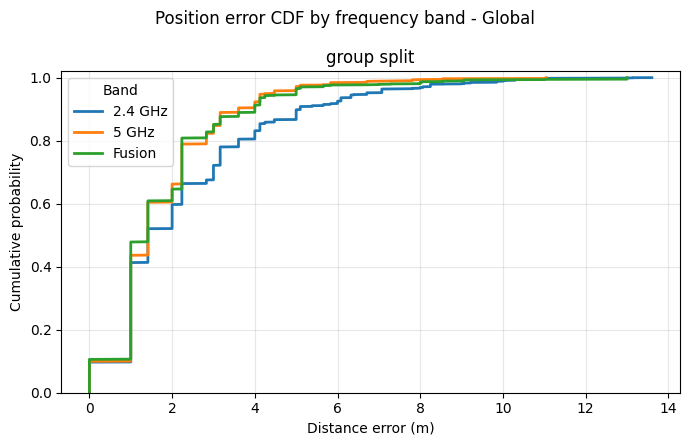

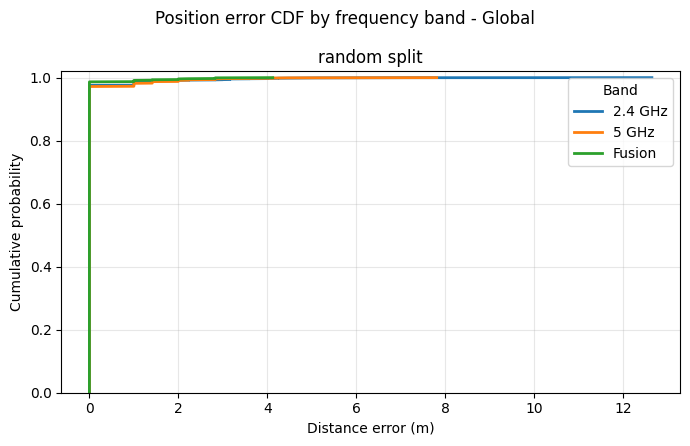

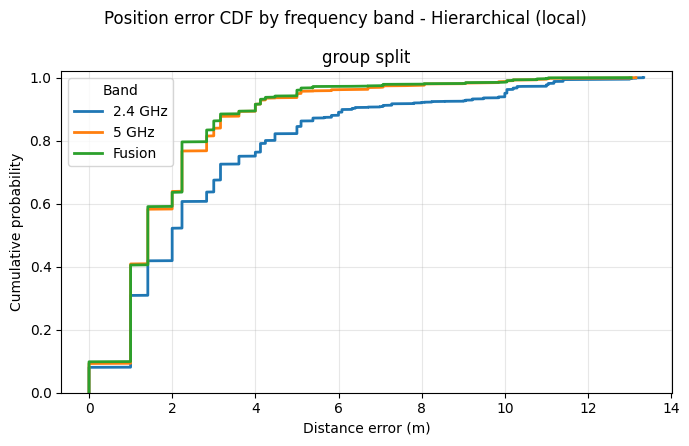

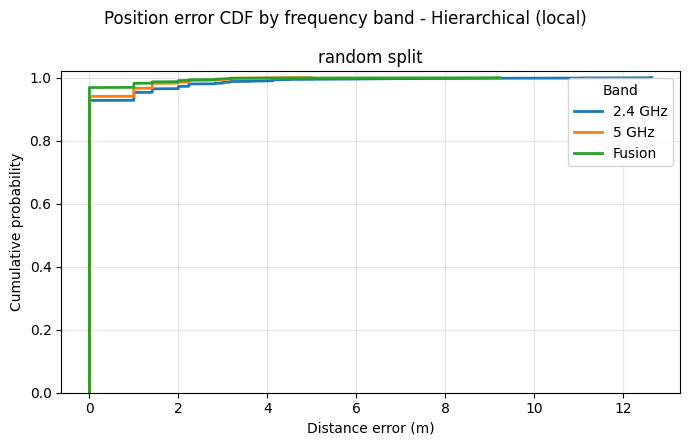

In [18]:
if SHOW_CDF_PLOTS:
    plot_band_error_cdf(global_all, model_label="Global")
    plot_band_error_cdf(hier_local_all, model_label="Hierarchical (local)")

### Box plot — distance error by frequency band

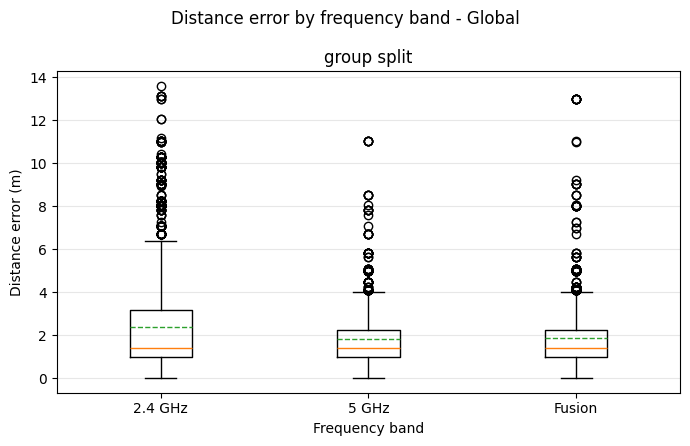

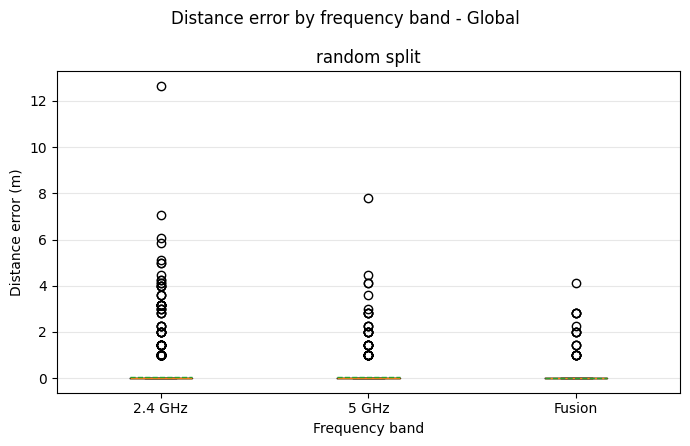

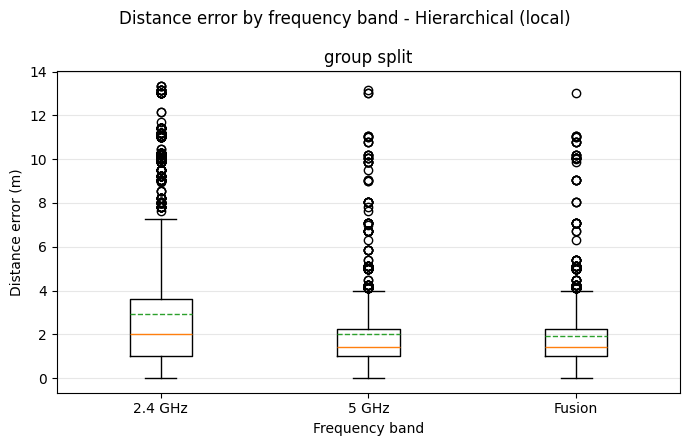

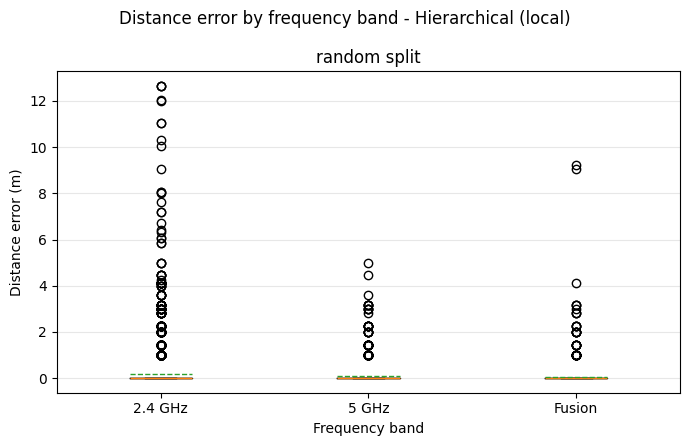

In [19]:
if SHOW_BOXPLOT:
    plot_band_error_boxplot(global_all, model_label="Global")
    plot_band_error_boxplot(hier_local_all, model_label="Hierarchical (local)")

## Floor Plan Heatmap

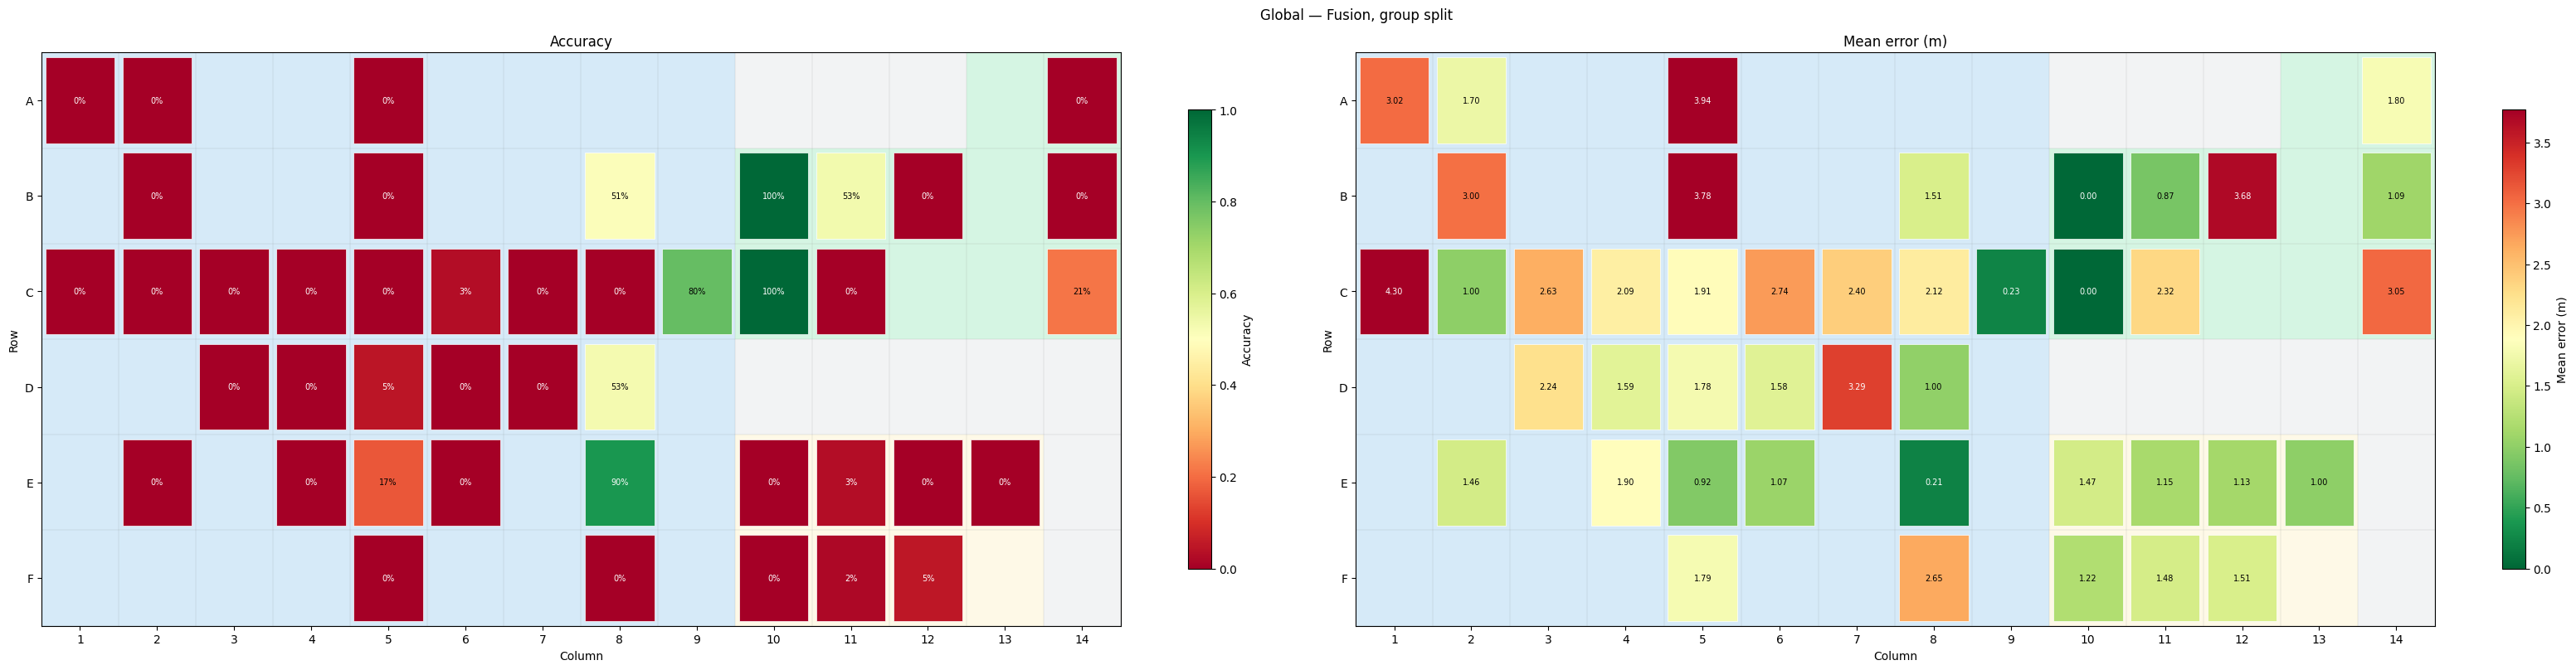

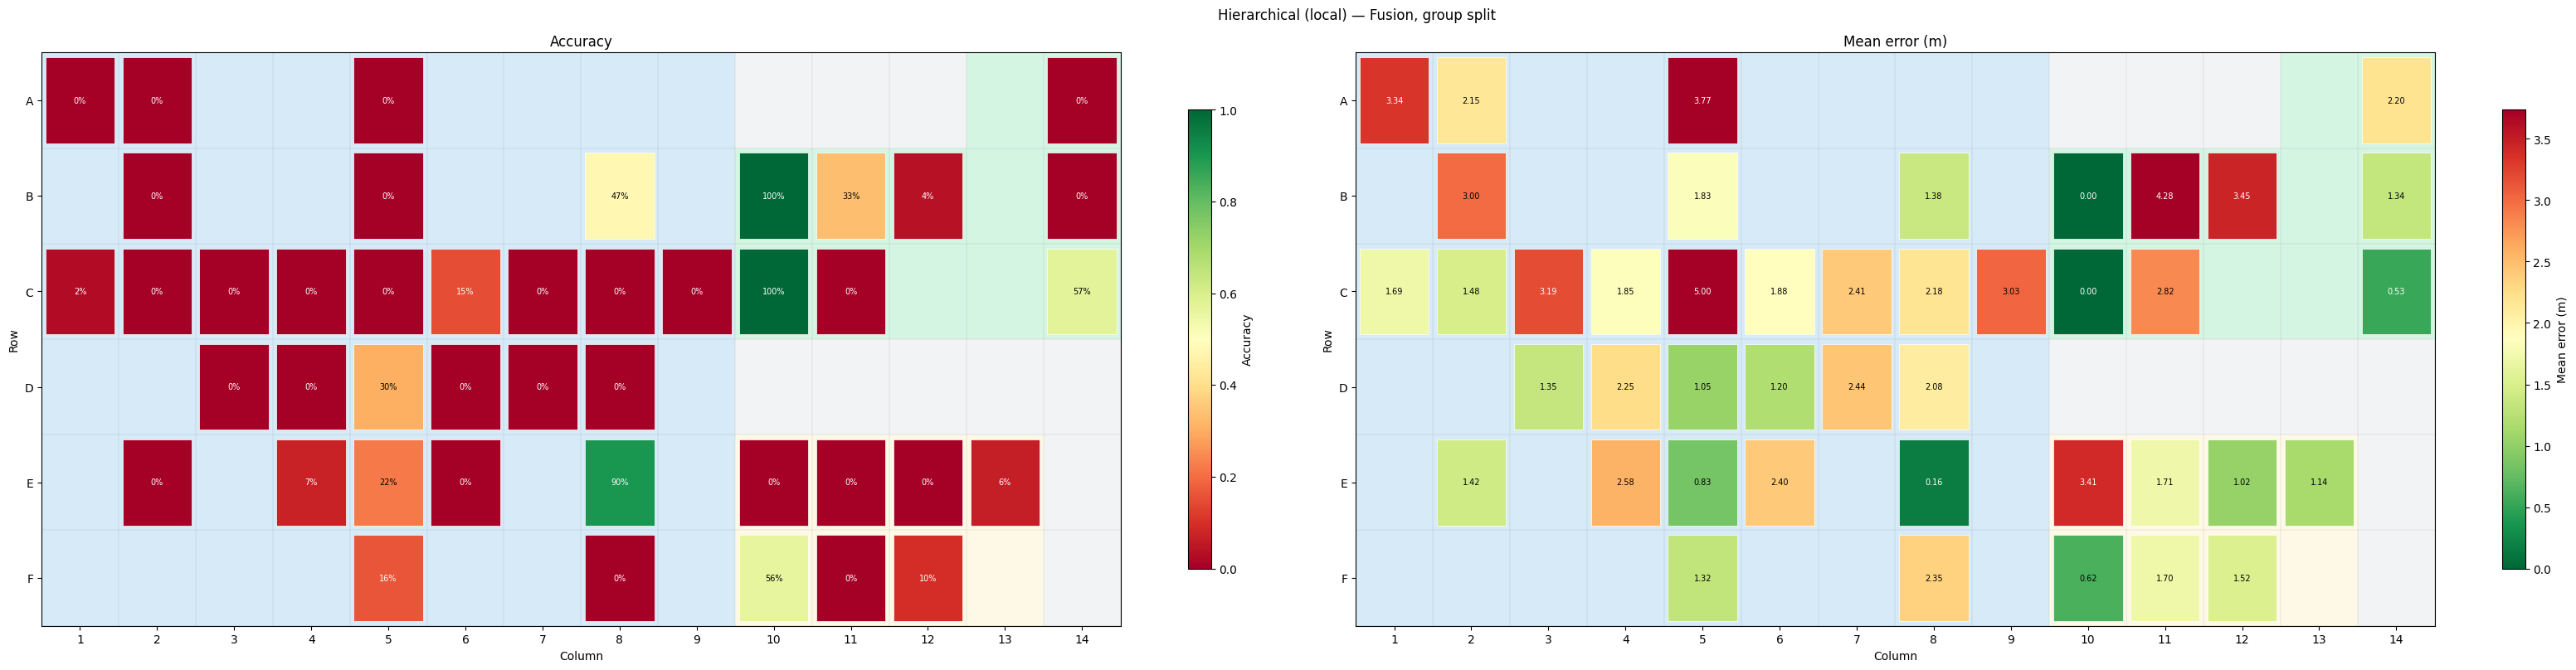

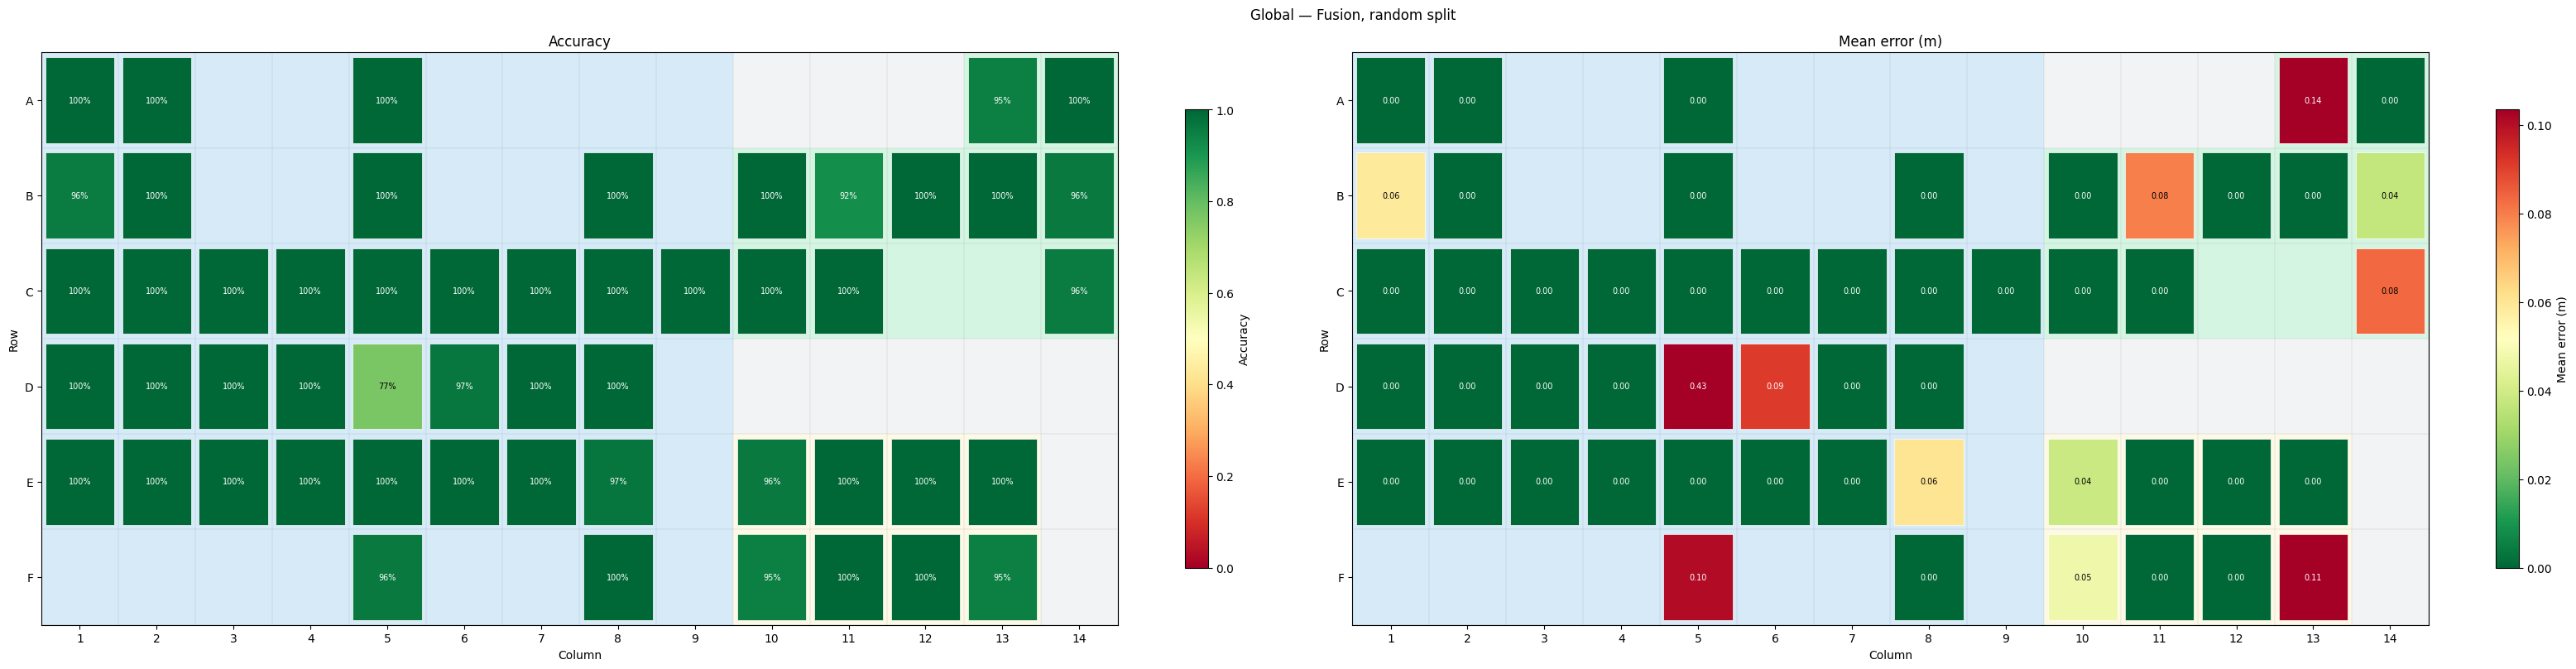

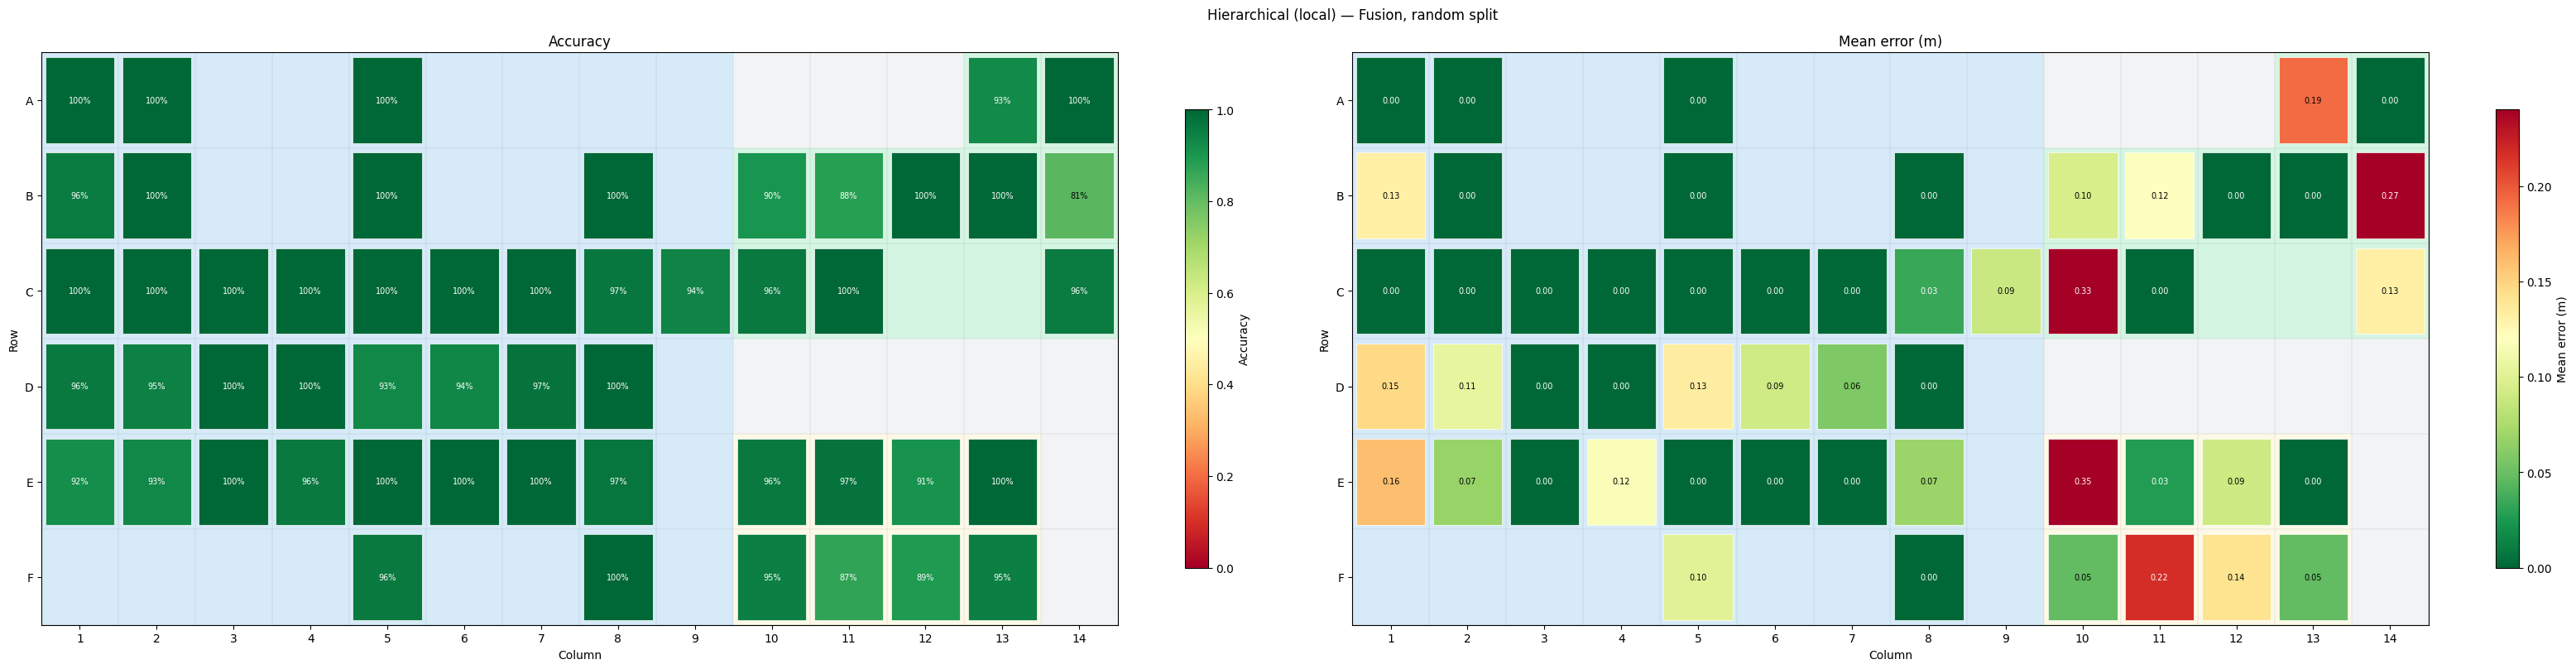

In [20]:
if SHOW_FLOOR_PLAN:
    for split_mode in SPLIT_MODES:
        for model_label, preds_dict in [
            ("Global", global_preds_by_split),
            ("Hierarchical (local)", hier_local_preds),
        ]:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                print(f"No predictions for {model_label} / {CONFUSION_DATASET} / {split_mode}")
                continue
            plot_floor_plan_heatmap(
                preds,
                title=f"{model_label} — {CONFUSION_DATASET}, {split_mode} split",
            )

## Position Confusion Matrices

In [21]:
if SHOW_CONFUSION_MATRICES:
    for model_label, preds_dict in [
        ("Global", global_preds_by_split),
        ("Hierarchical (local)", hier_local_preds),
    ]:
        for split_mode in SPLIT_MODES:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                continue
            tagged = preds.assign(model=model_label)
            print(f"\n--- {model_label} / {CONFUSION_DATASET} / {split_mode} split ---")
            plot_global_position_confusion_matrix(tagged, dataset=CONFUSION_DATASET)

## Per-Room Analysis — Hierarchical (local)

In [22]:
# Per-room accuracy and error breakdown for the local hierarchical model, both splits.
for split_mode in SPLIT_MODES:
    preds = hier_local_preds.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
    if preds.empty:
        print(f"No predictions for {CONFUSION_DATASET} / {split_mode}")
        continue
    print(f"\n=== Hierarchical (local) — {split_mode} split ===")
    display(per_room_hierarchical_summary(preds))

    if SHOW_PER_ROOM_PLOTS:
        tagged = preds.assign(model="Hierarchical (local)")
        plot_position_confusion_by_true_room(tagged, dataset=CONFUSION_DATASET)
        plot_position_confusion_when_room_correct(tagged, dataset=CONFUSION_DATASET)


=== Hierarchical (local) — group split ===


,dataset,true_room,samples,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,Fusion,2,237,0.886076,0.185654,2.124164,1.414214,3.461665
1,Fusion,1,940,0.993617,0.084043,1.959681,1.414214,2.357875
2,Fusion,3,279,0.921147,0.071685,1.643102,1.000000,2.414858
3,Fusion,0,44,0.000000,0.000000,NaN,NaN,NaN



=== Hierarchical (local) — random split ===


,dataset,true_room,samples,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,Fusion,1,963,0.998962,0.981308,0.037804,0.0,0.302293
1,Fusion,3,237,0.995781,0.940928,0.106715,0.0,0.665611
2,Fusion,2,292,0.993151,0.948630,0.111361,0.0,0.672350
3,Fusion,0,32,1.000000,1.000000,NaN,NaN,NaN
